In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import difflib
import os
from pathlib import Path
import re

import flopy
import pandas as pd

from rtmf6.postprocessing.plot import plot_compare_rtmf6_pht3d
from rtmf6.config import Config

In [3]:
config = Config('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/rtmf6.toml')

In [4]:
model_name = config.project_settings['project']['name']
component_models_dir = config.internal_paths.component_models_path
model_name

'cat_ex_1d'

In [6]:
%pwd

'/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d'

<Axes: xlabel='time (days)', ylabel=' concentrations (mmols/kgw)'>

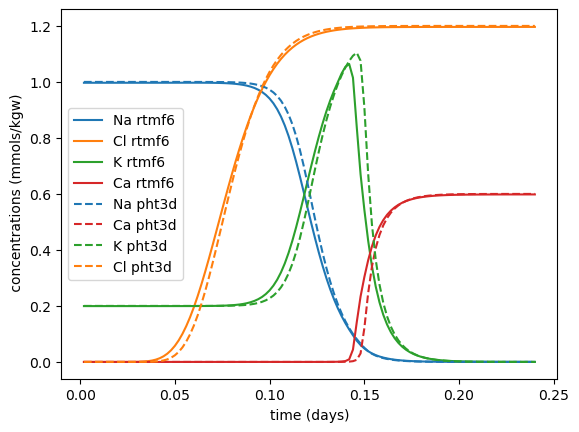

In [11]:
plot_compare_rtmf6_pht3d(
    config,
    pht3d_file='pht3d/out.dat',
    save_fig='result_advect.svg'
)

In [2]:
def read_conc_rtmf6(
    model_name, 
    component_models_dir, 
    components=('Na', 'Cl', 'K', 'Ca'), 
    steps=None
):
    """Plot concentrations."""
    conc = {}
    for path in component_models_dir.glob('*'):
        name = path.name
        if name in components:
            value = pd.read_csv(
                path / f'gwt_{model_name}.obs.csv',
                nrows=steps,
                )[['time', 'CONCENTRATION']]
            value.columns = ['time', name]
            value[name] *= 1_000
            conc[name] = value
    res = conc[components[0]]
    for name in components[1:]:
        res = pd.merge(res, conc[name])
    return res.set_index('time')

In [3]:
def read_conc_pht3d(file_name):
    df = pd.read_csv(file_name, sep=r'\s+', index_col='time_d')
    df.index.name = 'time'
    return df

df_pht3d = read_conc_pht3d('pht3d/out.dat')

In [4]:
clean_df_pht3d = df_pht3d[df_pht3d.cell==40].drop(columns=['cell']) * 1_000

In [5]:
clean_df_pht3d

,Na,Ca,K,Cl
time,,,,
0.002,1.000000,0.00000,0.200000,0.0
0.004,1.000000,0.00000,0.200000,0.0
0.006,0.999990,0.00000,0.200000,0.0
0.008,0.999990,0.00000,0.200000,0.0
0.010,0.999990,0.00000,0.200000,0.0
...,...,...,...,...
0.232,0.000003,0.59997,0.000055,1.2
0.234,0.000002,0.59998,0.000044,1.2
0.236,0.000002,0.59998,0.000035,1.2


In [6]:
df_rtmf6 = read_conc_rtmf6(
    model_name='cat_ex_1d', 
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [7]:
df_rtmf6

,Na,Cl,K,Ca
time,,,,
0.001,0.996999,0.000000e+00,0.199400,1.981313e-17
0.002,0.996999,1.217936e-13,0.199400,3.976317e-17
0.003,0.996999,6.583367e-13,0.199400,6.005352e-17
0.004,0.996999,2.394274e-12,0.199400,8.291046e-17
0.005,0.996999,7.601381e-12,0.199400,1.155372e-16
...,...,...,...,...
0.236,0.000015,1.196419e+00,0.000053,5.981804e-01
0.237,0.000014,1.196419e+00,0.000049,5.981826e-01
0.238,0.000014,1.196419e+00,0.000045,5.981846e-01


In [8]:
df_rtmf6_sel = df_rtmf6.loc[clean_df_pht3d.index] 
diff = df_rtmf6_sel - clean_df_pht3d

In [9]:
rtmf6 = df_rtmf6_sel.copy()
pht3d = clean_df_pht3d.copy()

In [10]:
rtmf6.columns = [col + ' rtmf6' for col in rtmf6.columns]

In [11]:
rtmf6

,Na rtmf6,Cl rtmf6,K rtmf6,Ca rtmf6
time,,,,
0.002,0.996999,1.217936e-13,0.199400,3.976317e-17
0.004,0.996999,2.394274e-12,0.199400,8.291046e-17
0.006,0.996999,2.203633e-11,0.199400,1.553211e-16
0.008,0.996999,1.576185e-10,0.199400,2.032558e-16
0.010,0.996999,1.019186e-09,0.199400,3.790078e-16
...,...,...,...,...
0.232,0.000017,1.196418e+00,0.000076,5.981687e-01
0.234,0.000016,1.196418e+00,0.000063,5.981752e-01
0.236,0.000015,1.196419e+00,0.000053,5.981804e-01


In [12]:
pht3d.columns = [col + ' pht3d' for col in pht3d.columns]

In [13]:
joined = rtmf6.join(pht3d)

In [20]:
%save join.py 8-13

The following commands were written to file `join.py`:
df_rtmf6_sel = df_rtmf6.loc[clean_df_pht3d.index] 
diff = df_rtmf6_sel - clean_df_pht3d
rtmf6 = df_rtmf6_sel.copy()
pht3d = clean_df_pht3d.copy()
rtmf6.columns = [col + ' rtmf6' for col in rtmf6.columns]
rtmf6
pht3d.columns = [col + ' pht3d' for col in pht3d.columns]
joined = rtmf6.join(pht3d)


In [14]:
{species: f'C{n}' for n, species in enumerate(dict.fromkeys(col.split()[0] for col in joined.columns))}

{'Na': 'C0', 'Cl': 'C1', 'K': 'C2', 'Ca': 'C3'}

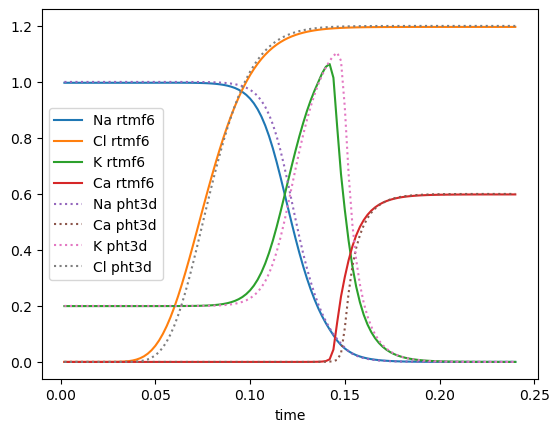

In [15]:
ax = joined.plot(style={name: ':' for name in joined.columns if name.endswith('pht3d')})

In [16]:
species_colors = {
    'Na': 'C0',   # blue
    'Cl': 'C1',   # orange
    'K': 'C2',    # green
    'Ca': 'C3'    # red
}

styles = []
for col in joined.columns:
    species = col.split()[0]
    linestyle = '-' if 'rtmf6' in col else '--'
    styles.append(f'{species_colors[species]}{linestyle}')

In [17]:
def plot_joined(joined):
    species_colors = {
        species: f'C{n}' for n, species in 
        enumerate(dict.fromkeys(col.split()[0] for col in joined.columns))}
    line_styles = {'rtmf6': '-', 'pht3d': '--'}
    styles = []
    for col in joined.columns:
        species, model_type = col.split()
        styles.append(f'{species_colors[species]}{line_styles[model_type]}')
    return joined.plot(style=styles)

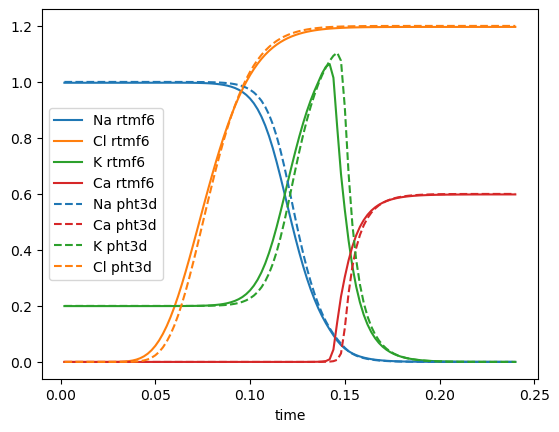

In [18]:
plot_joined(joined);

In [19]:
styles = [f'{species_colors[col.split()[0]]}{line_styles[col.split()[1]]}' for col in joined.columns]
styles

NameError: name 'line_styles' is not defined

In [ ]:
joined.plot(style=styles);

In [ ]:
diff.describe()

In [ ]:
clean_df_pht3d.describe()

In [ ]:
diff.plot()

In [ ]:

def plot(
    model_name, 
    component_models_dir, 
    components=('Na', 'Cl', 'K', 'Ca'), 
    steps=None
):
    """Plot concentrations."""
    conc = {}
    for path in component_models_dir.glob('*'):
        name = path.name
        if name in components:
            value = pd.read_csv(
                path / f'gwt_{model_name}.obs.csv',
                nrows=steps,
                )[['time', 'CENTER_LAYER_0']]
            value.columns = ['time', name]
            value[name] *= 1_000
            conc[name] = value
    res = conc[components[0]]
    for name in components[1:]:
        res = pd.merge(res, conc[name])
    return res.plot(x='time', ylabel='mmols/kgw')

In [ ]:
nlay = 1  # Number of layers
Lx = 0.08 #m Length of domain in x-direction (ncol * delr)
ncol = 40 # Number of columns
nrow = 1  # Number of rows
delr = Lx/ncol # Column spacing along a row ($m$)
tstep = 0.002 * 0.5

In [ ]:
def find_closest_match(query, dictionary):
    closest_match = difflib.get_close_matches(query, dictionary.keys(), n=1)
    if closest_match:
        return closest_match[0]
    else:
        return None

In [ ]:
## Read pht3d results

wd = 'pht3d'
# dx = 0.01
simdf = pd.read_csv(os.path.join(wd, 'out.dat'), sep = '\t', skipinitialspace=True, index_col=[0])
simdf.drop(simdf.columns[len(simdf.columns)-1], axis=1, inplace=True)

simdf.loc[:, 'x'] = simdf['cell'] * delr

simapi = pd.read_csv(os.path.join('mf6rtm','sout.csv'), sep = ',', skipinitialspace=True, index_col=[0])
simapi.loc[:, 'x'] = (simapi['cell'] + 1)*delr

#offset index of simapi by tstep
simapi.index = simapi.index + tstep

simapi

# get all ucn files in wd
ucn_files = [f for f in os.listdir(wd) if f.lower().endswith('.ucn')]
ucn_files

# get file that ends in py
pht3dpy = [f for f in os.listdir(wd) if f.endswith('py')]

#read pht3dpy file
ucndic = {}
pht3dpy = os.path.join(wd, pht3dpy[0])
with open(pht3dpy, 'r') as f:
    # print(f.read())
    for l in f:
        n =re.findall(r'\d+', l.split()[-1])[-1]
        ucndic[l.split()[0].replace('_', "")] = f"PHT3D{n}.UCN"
        
for k,v in ucndic.items():
    ucn = flopy.utils.HeadFile(os.path.join(wd, v),text=f"concentration")
    results = ucn.get_alldata()
    ucndic[k] = results
timespht3d = ucn.get_times()
    
for var in simapi.columns:
    closest_match = find_closest_match(var, ucndic)
    if closest_match:
        ucndic[var] = ucndic.pop(closest_match)


In [ ]:
ucndic.keys()

In [ ]:
simdf

In [ ]:
simdf[simdf.cell == 40].plot(y=['Na', 'Cl', 'K', 'Ca'])

In [ ]:
plot(
    model_name='cat_ex_1d', 
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [ ]:
df_rtmf6 = read_conc(
    model_name='cat_ex_1d', 
    component_models_dir=Path('/Users/mike/Dev/pymf6-project/rtmf6/benchmarks/cation_exchange_1d/rtmf6/.internal/component_models'))

In [ ]:
df